# Pomnażanie obrazów i przenoszenie nauki

In [2]:
import os

# Ustawienie PyTorch jako zaplecza dla biblioteki Keras
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
from keras import layers, datasets

import numpy as np
import PIL.Image as Image
import matplotlib.pylab as plt

# Sprawdzenie dostępności GPU
#print(tf.config.list_physical_devices('GPU'))
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    if torch.xpu.is_available():
        for i in range(torch.xpu.device_count()):
            print(f"XPU {i}: {torch.xpu.get_device_name(i)}")
    else:
        print("Brak dostępnych GPU lub XPU.")
        print("Używam CPU.")

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


GPU 0: AMD Radeon Graphics


/home/psokolow/.local/lib/python3.14/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


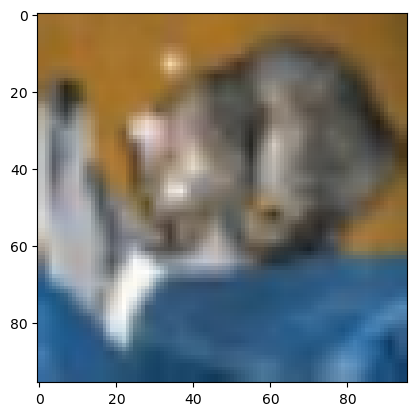

In [ ]:
IMAGE_SIZE = 96 #299
IMAGE_SHAPE = (IMAGE_SIZE, IMAGE_SIZE)
num_classes = 10

#(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
test_images = test_images[:100]
test_labels = test_labels[:100]

train_images = train_images[:5000]
train_labels = train_labels[:5000]

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
input_resize = layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)

plt.imshow(input_resize(train_images[0]).cpu())

In [5]:
def build_model(classifier):

    classifier.trainable = True  # Unfreeze the base model for fine-tuning
    # Create new model on top
    inputs = keras.Input(shape=(32, 32, 3))
    x = keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)(inputs)  # Resize input to match the base model

    # Simple data augmentation
    x = keras.layers.RandomFlip("horizontal")(x)

    # The base model contains batchnorm layers. We want to keep them in inference mode
    # when we unfreeze the base model for fine-tuning, so we make sure that the
    # base_model is running in inference mode here.
    x = classifier(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
    outputs = keras.layers.Dense(num_classes)(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable=True)

    return model

finetune_net = build_model(keras.applications.ResNet50V2(
                                                    weights="imagenet",
                                                    include_top=False, 
                                                    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))

scratch_net = build_model(keras.applications.ResNet50V2(
                                                    weights=None,
                                                    include_top=False, 
                                                    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 32, 32, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resizing_1 (Resizing)       │ (None, 96, 96, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 96, 96, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet50v2 (Functional)     │ (None, 3, 3, 2048)    │ 23,564,800 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     20,490 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 23,539,850 (89.80 MB)

 Non-trainable params: 45,440 (177.50 KB)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 32, 32, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resizing_2 (Resizing)       │ (None, 96, 96, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 96, 96, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet50v2 (Functional)     │ (None, 3, 3, 2048)    │ 23,564,800 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 10)            │     20,490 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 23,539,850 (89.80 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [ ]:
# Compile the model for multiclass classification
scratch_net.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train the model
history = scratch_net.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels),
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.5162 - loss: 1.4184 - val_accuracy: 0.3900 - val_loss: 5.0524
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.7032 - loss: 0.8725 - val_accuracy: 0.5700 - val_loss: 1.7848
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.7676 - loss: 0.6833 - val_accuracy: 0.6000 - val_loss: 1.2096
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.7986 - loss: 0.5892 - val_accuracy: 0.5800 - val_loss: 1.5244
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.8414 - loss: 0.4783 - val_accuracy: 0.5900 - val_loss: 1.3603
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.8644 - loss: 0.4082 - val_accuracy: 0.7000 - val_loss: 0.9818
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8854 - loss: 0.3379 - val_accuracy: 0.6900 - val_loss: 1.1188
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.9010 - loss: 0.2934 - val_accu

4/4 - 0s - 80ms/step - accuracy: 0.6600 - loss: 1.1954


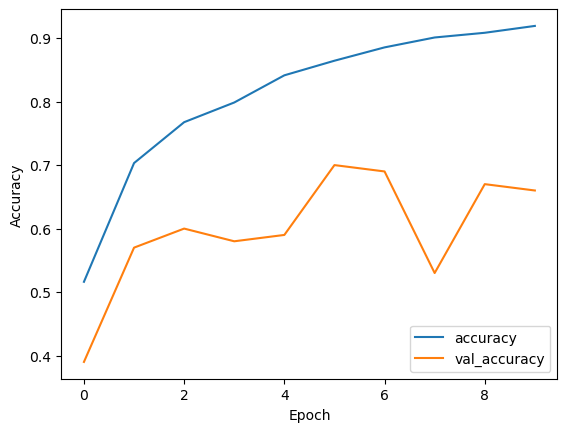

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = scratch_net.evaluate(test_images,  test_labels, verbose=2)

## Zadania

1. Wytrenuj model bez pomnażania obrazów. Porównaj celność treningową jak też i testową z oraz bez pomnażania obrazów. Czy ten eksperyment porównawczy popiera argument, że pomnażanie obrazów może ograniczać nadmierne dopasowanie? Dlaczego?
2. Wymieszaj różne metody poszerzania zbiorów danych na zbiorze CIFAR-10. Czy poprawiaja one celność?
3. Zwiększ współczynnik uczenia w `finetune_net`. Jak zmieni się celność predykcji modelu?
4. Kontynuuj dostosowywanie hiperparametrów obu sieci w eksperymencie porównawczym. Czy nadal ich trafność predykcji różni się?
5. Ustaw parametry wszystkich warstw z wyjątkiem wyjściowej w siei `finetune_net` na te ze źródłowego modelu i nie aktualizuj ich podczas trningu. Jak zmieni się celność modelu?